# Day 3 - EDA Analysis
Bluestock MF Project — exploratory analysis on the cleaned datasets and SQLite DB.

**One-time setup:** plotly needs Chrome installed to export PNG images. Run this once in a terminal
(not needed every time, just the first time):
```
plotly_get_chrome
```
If you skip this, the charts will still display fine in the notebook (`fig.show()`), the PNG export line will just print a warning instead of crashing.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os

sns.set_style("whitegrid")
os.makedirs("reports/charts", exist_ok=True)

def save_plotly(fig, path):
    try:
        fig.write_image(path)
    except Exception as e:
        print(f"Could not export {path} (run 'plotly_get_chrome' in terminal once to enable PNG export): {e}")

conn = sqlite3.connect("bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", conn, parse_dates=["date"])
fund = pd.read_sql("SELECT * FROM dim_fund", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)
tx = pd.read_sql("SELECT * FROM fact_transactions", conn, parse_dates=["date"])
aum = pd.read_sql("SELECT * FROM fact_aum", conn, parse_dates=["date"])

sip = pd.read_csv("data/processed/04_monthly_sip_inflows.csv")
cat_inflow = pd.read_csv("data/processed/05_category_inflows.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count.csv")
holdings = pd.read_csv("data/processed/09_portfolio_holdings.csv")

nav = nav.merge(fund[["amfi_code", "scheme_name", "fund_house", "category"]], on="amfi_code", how="left")


## 1. NAV Trend Analysis
Daily NAV for all 40 schemes, 2022-2026, with the 2023 bull run and 2024 correction highlighted.

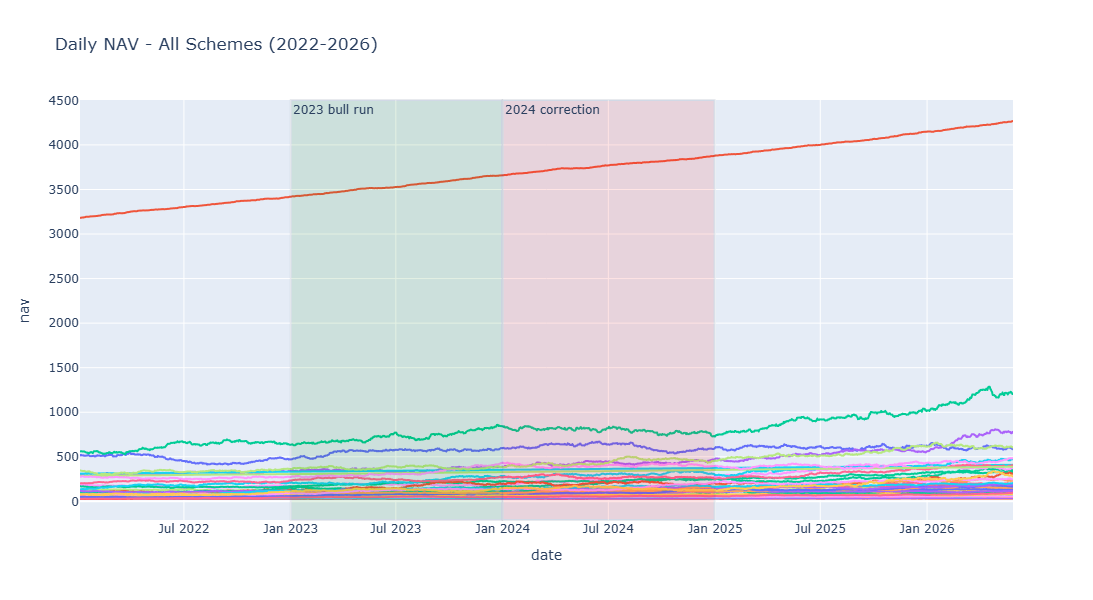

In [3]:

fig = px.line(nav, x="date", y="nav", color="scheme_name",
              title="Daily NAV - All Schemes (2022-2026)")

# highlight periods - adjust these date ranges based on what the data actually shows
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
              annotation_text="2023 bull run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.1,
              annotation_text="2024 correction", annotation_position="top left")

fig.update_layout(showlegend=False, height=600)
save_plotly(fig, "reports/charts/01_nav_trend.png")
fig.show()


## 2. AUM Growth by Fund House
Grouped bar chart, AUM per fund house per year, SBI highlighted.

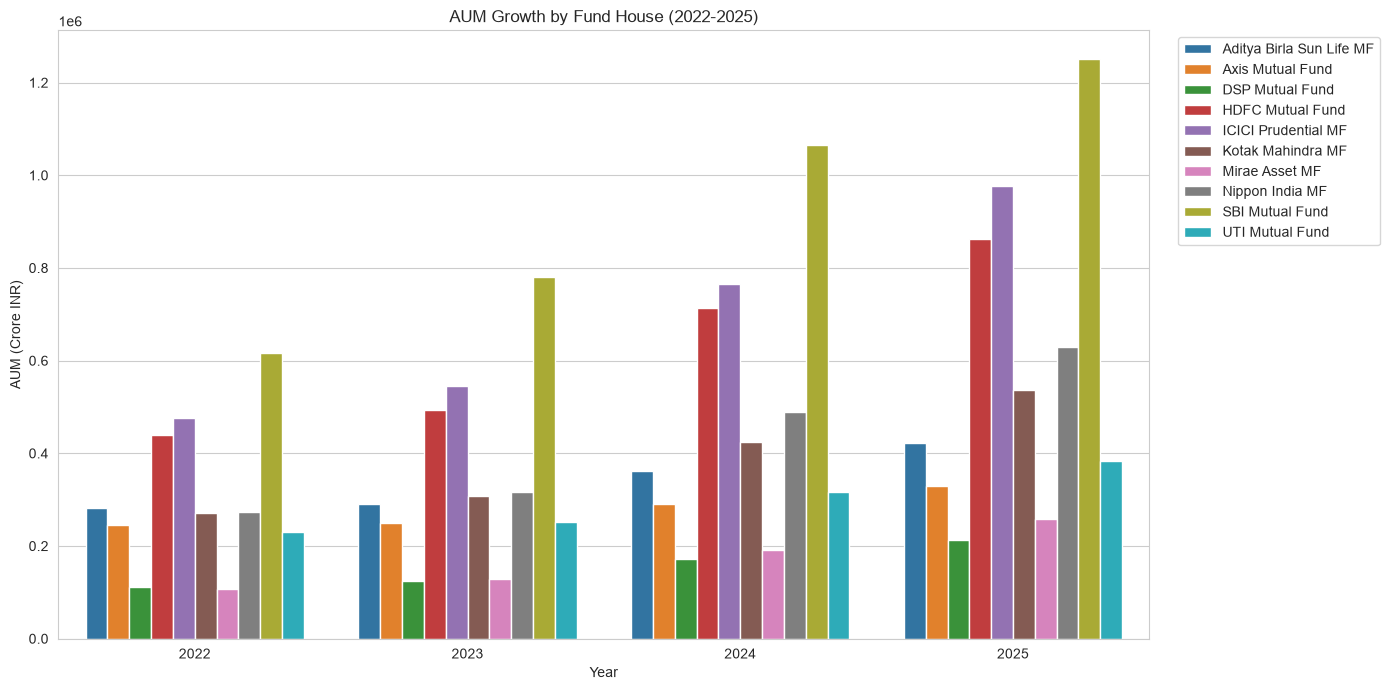

Top fund house by year:
    year       fund_house     aum_crore
8   2022  SBI Mutual Fund  6.175000e+05
18  2023  SBI Mutual Fund  7.810000e+05
28  2024  SBI Mutual Fund  1.064667e+06
38  2025  SBI Mutual Fund  1.250000e+06


In [4]:

aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()

plt.figure(figsize=(14, 7))
colors = ["#c0392b" if fh == "SBI Mutual Fund" else "#3498db" for fh in aum_yearly["fund_house"].unique()]
ax = sns.barplot(data=aum_yearly, x="year", y="aum_crore", hue="fund_house")
plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Crore INR)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("reports/charts/02_aum_growth.png", dpi=150)
plt.show()

top_fh = aum_yearly.loc[aum_yearly.groupby("year")["aum_crore"].idxmax()]
print("Top fund house by year:")
print(top_fh)


## 3. SIP Inflow Time Series
Monthly SIP trend Jan 2022 - Dec 2025, with the all-time high annotated.

Could not export reports/charts/03_sip_inflow.png (run 'plotly_get_chrome' in terminal once to enable PNG export): Type is not JSON serializable: Timestamp


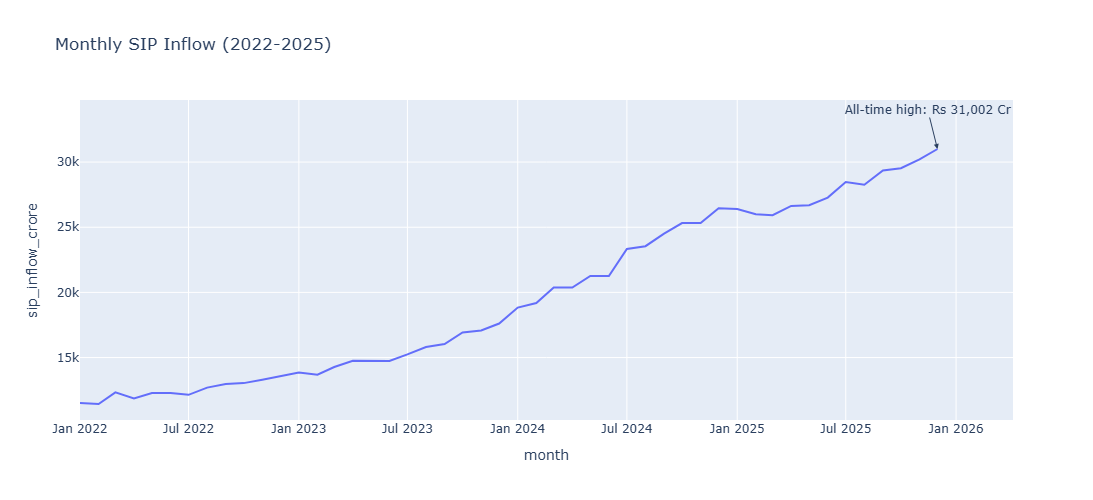

In [5]:

sip["month"] = pd.to_datetime(sip["month"])
sip_sorted = sip.sort_values("month")

fig = px.line(sip_sorted, x="month", y="sip_inflow_crore", title="Monthly SIP Inflow (2022-2025)")

peak_row = sip_sorted.loc[sip_sorted["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=peak_row["month"], y=peak_row["sip_inflow_crore"],
                    text=f"All-time high: Rs {peak_row['sip_inflow_crore']:,} Cr",
                    showarrow=True, arrowhead=2, ay=-40)

fig.update_layout(height=500)
save_plotly(fig, "reports/charts/03_sip_inflow.png")
fig.show()


## 4. Category Inflow Heatmap
Months on X-axis, categories on Y-axis, net inflow as colour intensity.

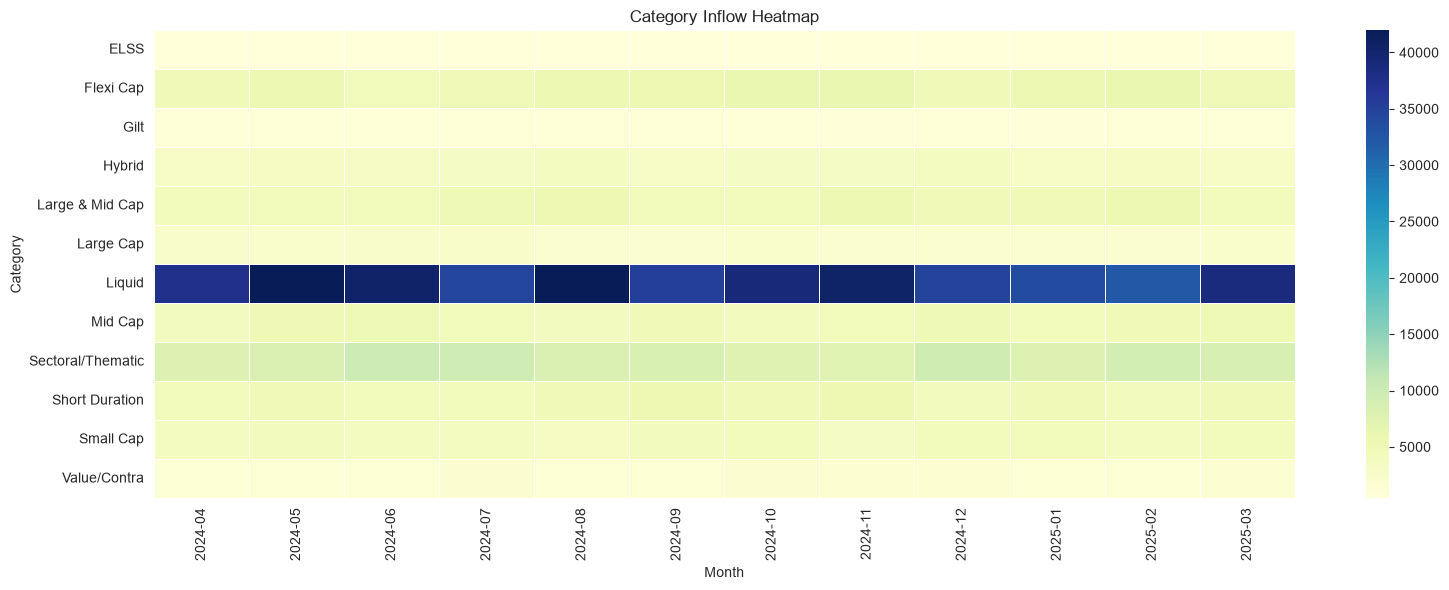

In [6]:

pivot = cat_inflow.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap="YlGnBu", linewidths=0.5, annot=False)
plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("reports/charts/04_category_heatmap.png", dpi=150)
plt.show()


## 5. Investor Demographics
Age group distribution, SIP amount by age group, gender split.

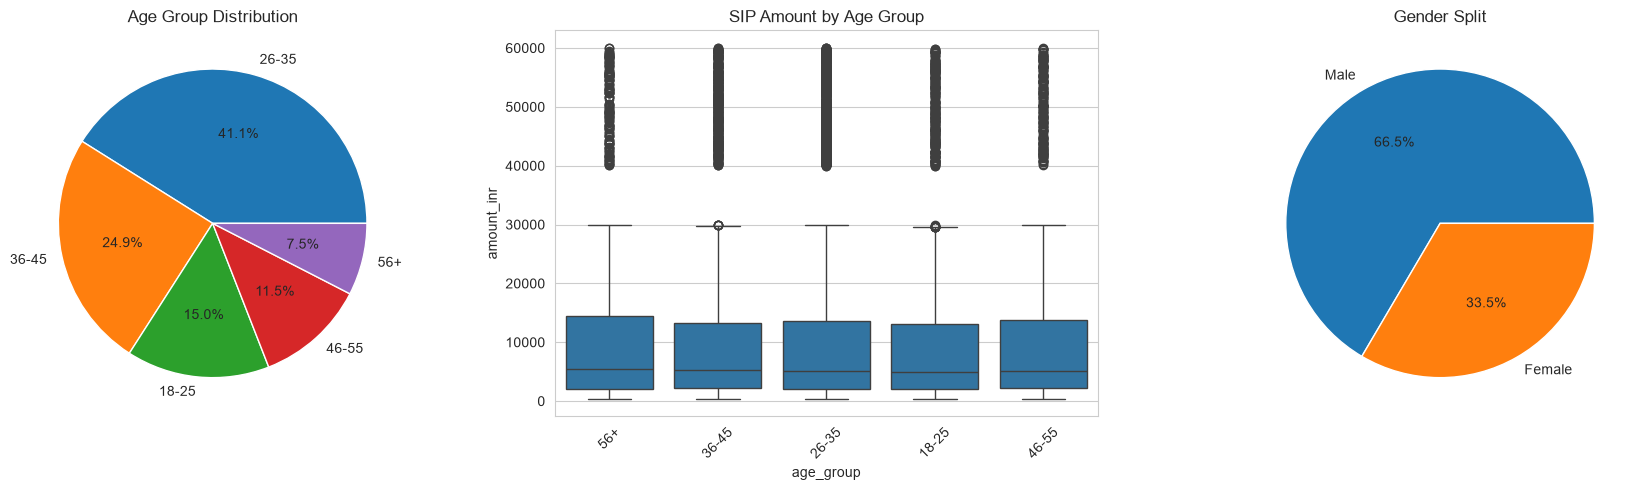

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_counts = tx["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
axes[0].set_title("Age Group Distribution")

sip_tx = tx[tx["transaction_type"] == "SIP"]
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].tick_params(axis="x", rotation=45)

gender_counts = tx["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig("reports/charts/05_demographics.png", dpi=150)
plt.show()


## 6. Geographic Distribution
SIP amount by state, T30 vs B30 city tier split.

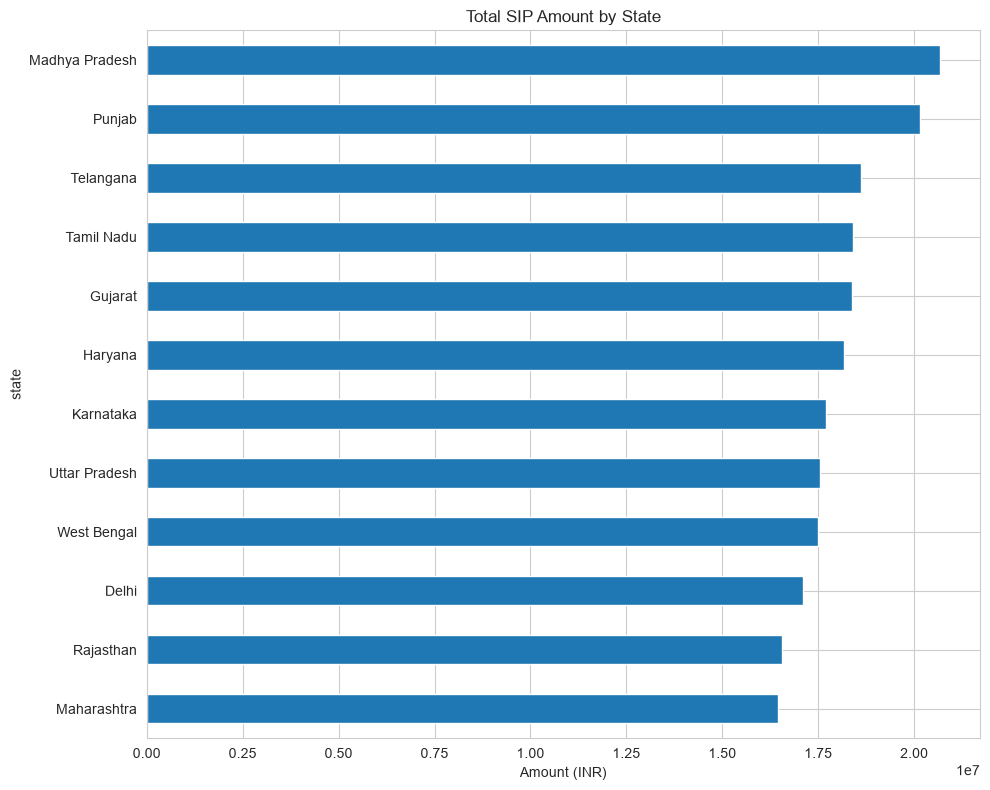

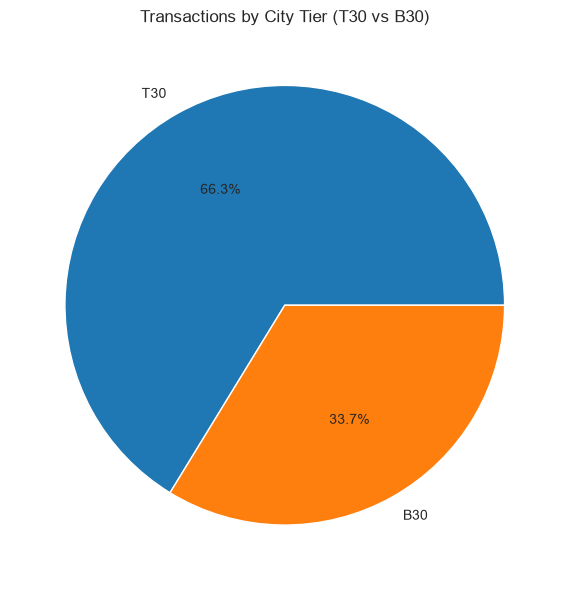

In [8]:

state_sip = sip_tx.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10, 8))
state_sip.plot(kind="barh")
plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.savefig("reports/charts/06a_state_sip.png", dpi=150)
plt.show()

# T30 = tier 1 cities, B30 = tier 2/3 (adjust mapping if your city_tier values differ)
tier_map = tx["city_tier"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(tier_map, labels=tier_map.index, autopct="%1.1f%%")
plt.title("Transactions by City Tier (T30 vs B30)")
plt.tight_layout()
plt.savefig("reports/charts/06b_city_tier.png", dpi=150)
plt.show()


## 7. Folio Count Growth
Total folios from Jan 2022 to Dec 2025, with key milestones marked.

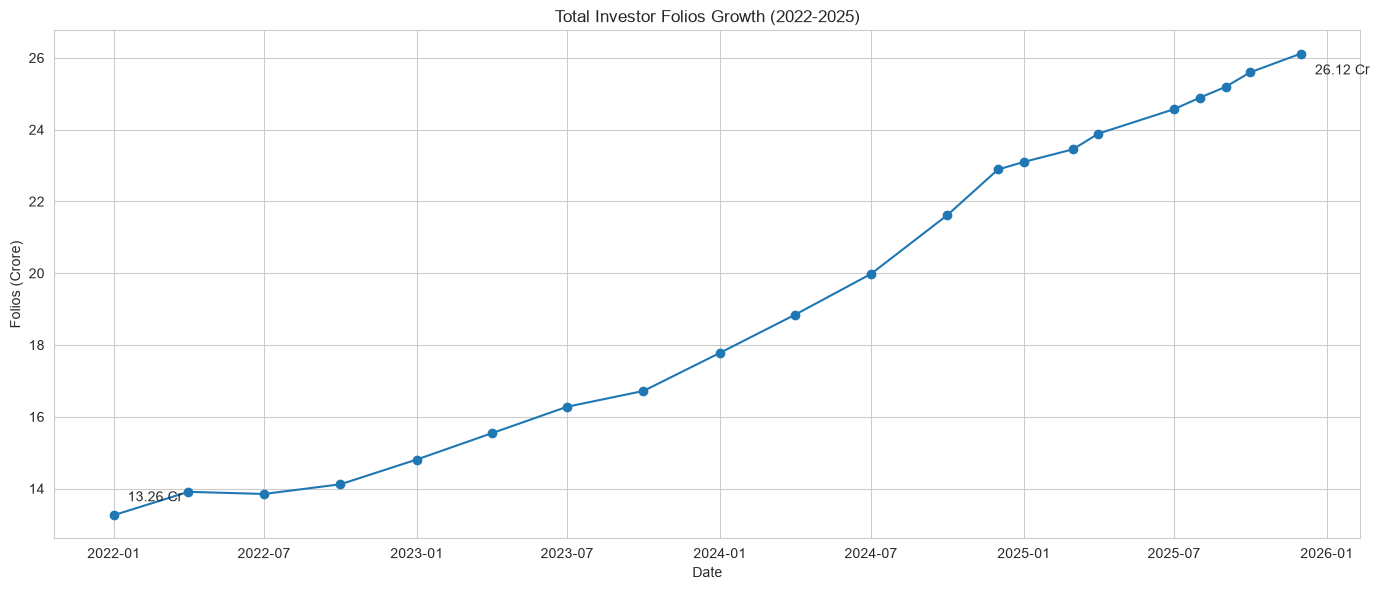

In [9]:

folio["month"] = pd.to_datetime(folio["month"])
folio_sorted = folio.sort_values("month")

plt.figure(figsize=(14, 6))
plt.plot(folio_sorted["month"], folio_sorted["total_folios_crore"], marker="o")
plt.title("Total Investor Folios Growth (2022-2025)")
plt.ylabel("Folios (Crore)")
plt.xlabel("Date")

start = folio_sorted.iloc[0]
end = folio_sorted.iloc[-1]
plt.annotate(f"{start['total_folios_crore']} Cr", xy=(start["month"], start["total_folios_crore"]),
             xytext=(10, 10), textcoords="offset points")
plt.annotate(f"{end['total_folios_crore']} Cr", xy=(end["month"], end["total_folios_crore"]),
             xytext=(10, -15), textcoords="offset points")

plt.tight_layout()
plt.savefig("reports/charts/07_folio_growth.png", dpi=150)
plt.show()


## 8. NAV Return Correlation Matrix
Pairwise correlation of daily returns for 10 selected funds.

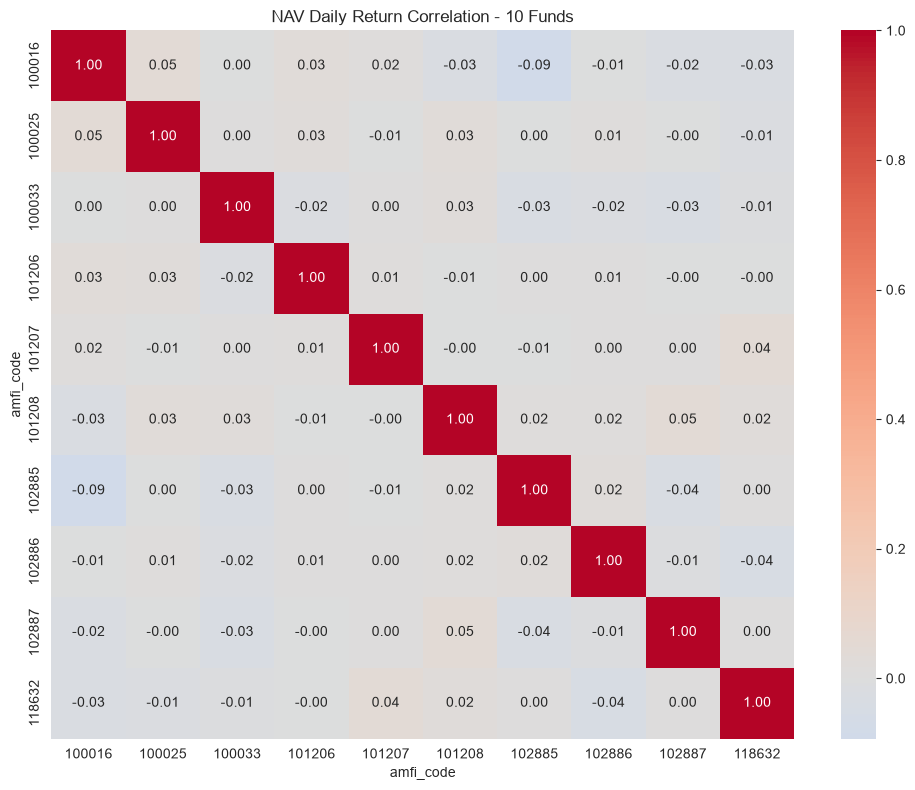

In [10]:

top10_codes = fund["amfi_code"].unique()[:10]
nav_wide = nav[nav["amfi_code"].isin(top10_codes)].pivot(index="date", columns="amfi_code", values="nav")
returns = nav_wide.pct_change().dropna()

corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NAV Daily Return Correlation - 10 Funds")
plt.tight_layout()
plt.savefig("reports/charts/08_correlation_matrix.png", dpi=150)
plt.show()


## 9. Sector Allocation Donut
Aggregate sector weights across all equity fund holdings.

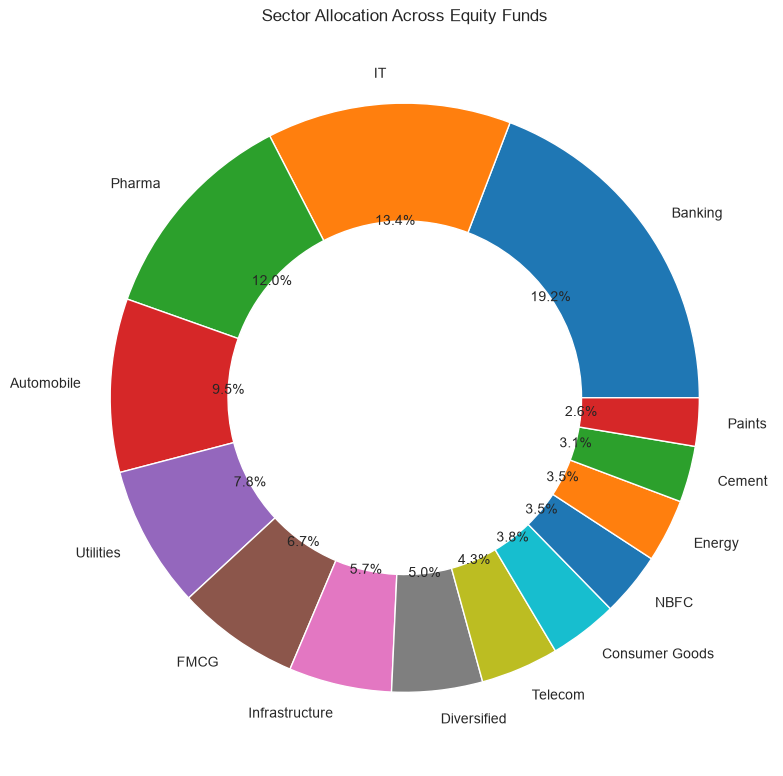

In [11]:

sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%",
        wedgeprops=dict(width=0.4))
plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig("reports/charts/09_sector_donut.png", dpi=150)
plt.show()


## 10. Key EDA Findings

Fill in each insight after reviewing the charts above - one sentence per finding, referencing the chart it comes from.

1. **NAV trend (chart 1):** _[insight here]_
2. **AUM growth (chart 2):** _[insight here]_
3. **SIP inflow (chart 3):** _[insight here]_
4. **Category inflow (chart 4):** _[insight here]_
5. **Demographics (chart 5):** _[insight here]_
6. **Geography (chart 6):** _[insight here]_
7. **Folio growth (chart 7):** _[insight here]_
8. **Correlation (chart 8):** _[insight here]_
9. **Sector allocation (chart 9):** _[insight here]_
10. **Overall:** _[insight here]_


In [12]:
conn.close()
print('done - charts saved in reports/charts/')

done - charts saved in reports/charts/
